# Reto - Clasificación MNIST
`Sergio Andres Amortegui Ardila`


# Introducción

Este notebook presenta una solución end-to-end para la clasificación de dígitos escritos a mano con el dataset MNIST. El objetivo no es solo entrenar un modelo que tenga buen desempeño en la partición de prueba del benchmark, sino también explicar el razonamiento detrás de cada paso: cómo se preparan los datos, por qué la arquitectura del modelo es apropiada, cómo se monitorea el entrenamiento y qué dicen las métricas de evaluación sobre el comportamiento predictivo real.

La mayoría de los detalles de implementación viven en el paquete `src/` en lugar de estar dentro de las celdas del notebook. Esto mantiene el notebook enfocado en la narrativa analítica, al mismo tiempo que conserva cualidades orientadas a producción como separación de responsabilidades, modularidad, escalabilidad y legibilidad. Por lo tanto, el notebook actúa como el reporte del experimento, mientras que la lógica reutilizable de datos, modelo, entrenamiento, visualización y preprocesamiento permanece en módulos dedicados.

El flujo de trabajo sigue cinco etapas:
1. Cargar e inspeccionar las particiones de entrenamiento, validación y prueba de MNIST.
2. Aplicar aumento de datos durante el entrenamiento para mejorar la robustez más allá de dígitos de benchmark perfectamente centrados.
3. Entrenar una red neuronal convolucional compacta adecuada para clasificación de imágenes.
4. Evaluar el desempeño con pérdida, exactitud, matriz de confusión, precisión, recall, F1-score y log loss.
5. Probar el modelo entrenado en muestras personalizadas de dígitos escritos a mano para revisar qué tan bien se transfiere el desempeño del benchmark a entradas menos controladas.

El notebook está escrito en español. La versión en inglés está referenciada en `/notebooks/challenge.ipynb`.


## Configuración de Autoreload

Autoreload mantiene el notebook sincronizado con los cambios hechos en los módulos locales de `src/`. Esto es útil porque la mayor parte de la lógica de implementación se mantiene intencionalmente fuera del notebook.


In [1]:
%load_ext autoreload
%autoreload 2

# Imports Requeridos

Los imports están agrupados por responsabilidad: módulos estándar, librerías externas, cargadores de datos del proyecto, definición del modelo, utilidades de entrenamiento, métricas, funciones auxiliares de visualización y funciones de preprocesamiento. Esto refleja la estructura del proyecto y hace que el notebook sea más fácil de auditar.


In [2]:
# Módulos
import os
import sys
from pathlib import Path

import pandas as pd
import torch

# Agregar la raíz del proyecto al path para poder importar desde src
sys.path.append(os.path.abspath(".."))

# Métricas
from sklearn.metrics import log_loss

# Dataloaders de MNIST
from src.data.mnist import load_mnist_dataloaders

# Red neuronal personalizada
from src.models.mnist_cnn import MNISTCNN

# Bucle de entrenamiento
from src.training.engine import test_model, train

# Utilidades
from src.utils.device import get_device

# EDA mínimo
from src.utils.eda import (
    get_class_distribution,
    inspect_dataloader,
)

# Esquemas
from src.utils.lib.schema import TrainHistory

# Gráficas
from src.utils.plot import (
    plot_class_distribution,
    plot_confusion_matrix,
    plot_hw_samples,
    plot_nn_architecture,
    plot_predictions,
    plot_samples,
    plot_train_history,
    print_classification_report,
)

# Preprocesamiento de datos y transformaciones
from src.utils.preprocessing import preprocess_handwritten_image_with_transformation

# Dataset MNIST

MNIST contiene imágenes en escala de grises de dígitos escritos a mano del 0 al 9. La tarea es un problema supervisado de clasificación multiclase: para cada imagen, el modelo debe asignar exactamente una de las diez etiquetas de dígitos.

La función auxiliar `load_mnist_dataloaders` construye tres dataloaders:
1. `train_loader`: usado para ajustar los parámetros del modelo.
2. `eval_loader`: usado durante el entrenamiento para monitorear la generalización en datos no utilizados para actualizaciones por gradiente.
3. `test_loader`: reservado hasta la evaluación final.

También retorna `metadata`, que resume los tamaños de las particiones y los nombres de las clases.


In [3]:
# Cargar dataloaders de MNIST
train_loader, eval_loader, test_loader, metadata = load_mnist_dataloaders()

La función de carga crea objetos de dataset separados para que el entrenamiento y la evaluación puedan usar transformaciones distintas.

La transformación de entrenamiento aplica aumento de datos ligero:
1. Redimensionamiento a 28 x 28 píxeles.
2. Rotación aleatoria de hasta 10 grados.
3. Traslación afín aleatoria y cambios de escala.
4. Inversión aleatoria del color con probabilidad 0.5.
5. Conversión a tensor.
6. Normalización con media `0.1307` y desviación estándar `0.3081`, estimadas en `/notebooks/experiments.ipynb`.

Las transformaciones de validación y prueba son deterministas:
1. Redimensionamiento a 28 x 28 píxeles.
2. Conversión a tensor.
3. La misma normalización de MNIST.

Este diseño le da al modelo más variación durante el entrenamiento, mientras mantiene estables las mediciones de validación y prueba. El objetivo es hacer que el clasificador dependa menos de dígitos perfectamente centrados y alineados, y que sea más tolerante al tipo de variación observado en entradas reales escritas a mano.


## Inspección de Dataloaders

Antes de modelar, verificamos los metadatos de las particiones y la estructura de los batches. Esto comprueba que el número esperado de muestras, las formas de las imágenes y las etiquetas estén fluyendo correctamente por el pipeline.


In [4]:
for k, v in metadata.items():
    print(f"{k}: {v}")

train_size: 54000
train_percentage: 77.14%
test_size: 10000
test_percentage: 14.29%
validation_size: 6000
validation_percentage: 8.57%
classes: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


In [5]:
inspect_dataloader(train_loader, "Train")
inspect_dataloader(eval_loader, "Eval")
inspect_dataloader(test_loader, "Test")


Train loader
----------------------------------------
Number of batches: 844
Batch image shape: torch.Size([64, 1, 28, 28])
Batch label shape: torch.Size([64])
Image dtype: torch.float32
Label dtype: torch.int64
Image min: -0.4242
Image max: 2.8215
Labels in first batch: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Eval loader
----------------------------------------
Number of batches: 94
Batch image shape: torch.Size([64, 1, 28, 28])
Batch label shape: torch.Size([64])
Image dtype: torch.float32
Label dtype: torch.int64
Image min: -0.4242
Image max: 2.8215
Labels in first batch: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Test loader
----------------------------------------
Number of batches: 157
Batch image shape: torch.Size([64, 1, 28, 28])
Batch label shape: torch.Size([64])
Image dtype: torch.float32
Label dtype: torch.int64
Image min: -0.4242
Image max: 2.8215
Labels in first batch: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


## Distribución de Clases

El balance de clases importa porque métricas agregadas fuertes pueden ocultar un mal comportamiento en clases minoritarias. Aquí comparamos los conteos de dígitos en las particiones de entrenamiento, validación y prueba.


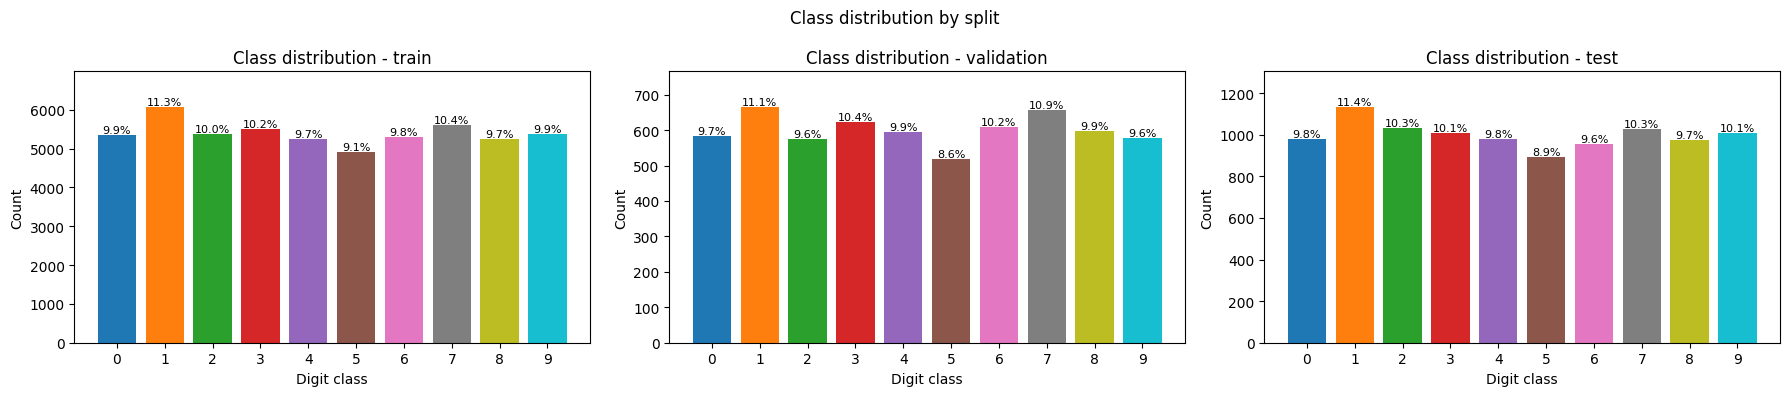

In [6]:
train_dist = get_class_distribution(train_loader, "train")
val_dist = get_class_distribution(eval_loader, "validation")
test_dist = get_class_distribution(test_loader, "test")

class_distribution = pd.concat([train_dist, val_dist, test_dist])

plot_class_distribution(class_distribution)

Los conteos de clases están bastante balanceados en las tres particiones, por lo que no se requiere reponderación de clases, corrección por muestreo ni estrategia de imputación. Esto también significa que la exactitud es una métrica inicial significativa, aunque las métricas por clase siguen siendo necesarias para confirmar que el desempeño sea consistente entre dígitos.


## Muestras por Partición

La inspección visual ayuda a validar tanto los datos crudos como el pipeline de aumento de datos. Los ejemplos de entrenamiento deberían mostrar variación controlada, mientras que los ejemplos de validación y prueba deberían permanecer representativos de la distribución original del benchmark.


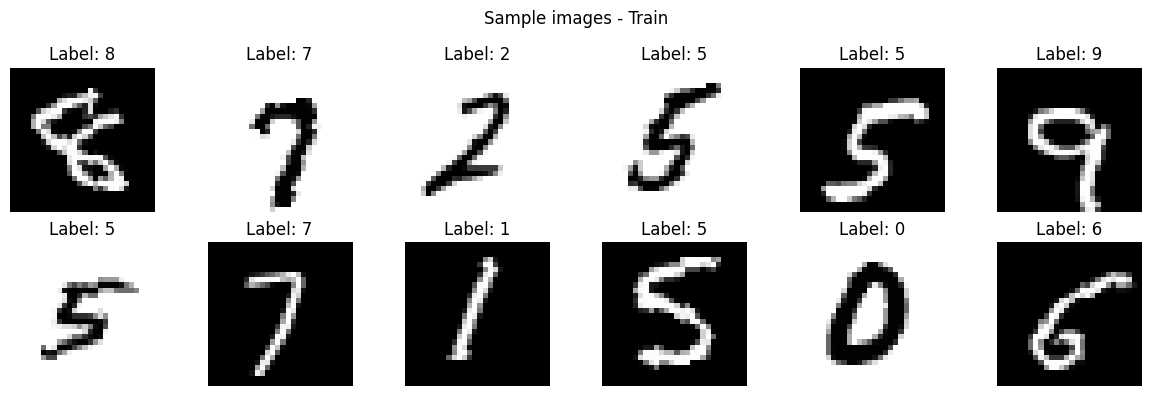

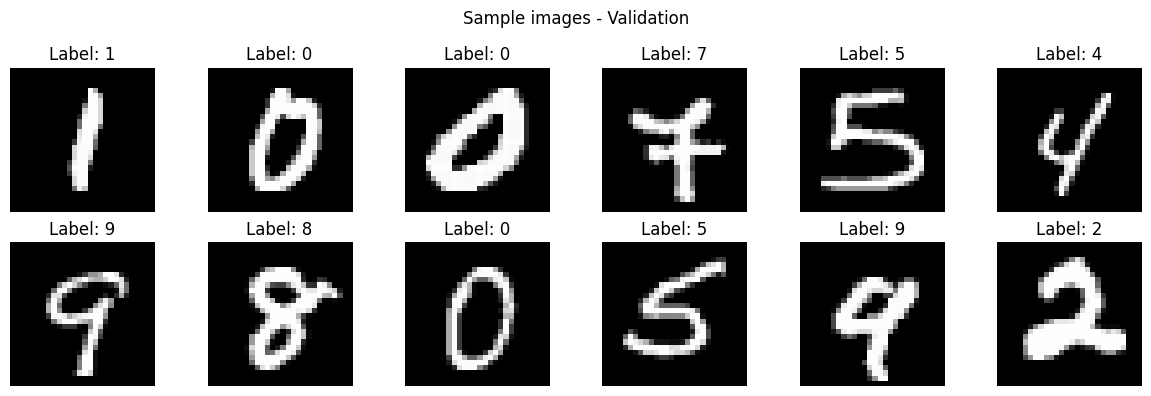

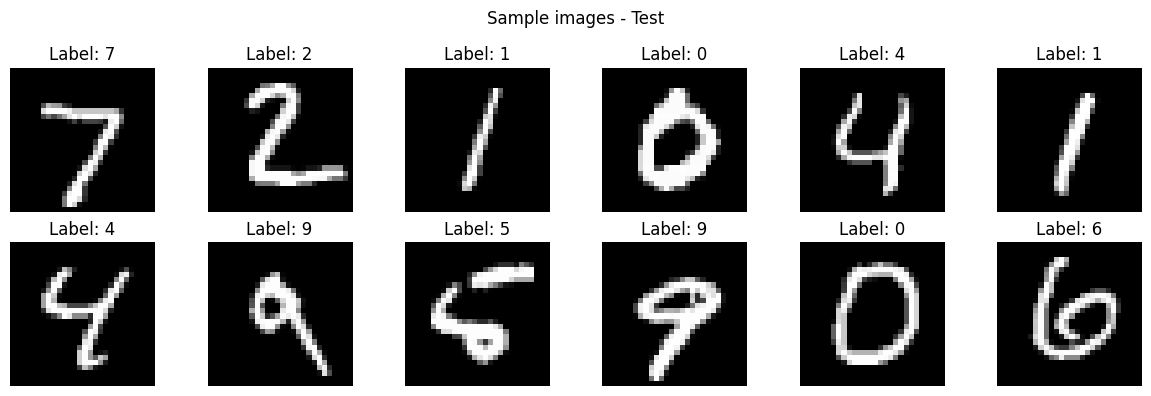

In [7]:
plot_samples(train_loader, "Train")
plot_samples(eval_loader, "Validation")
plot_samples(test_loader, "Test")

Las muestras de entrenamiento muestran los efectos esperados del aumento de datos, incluyendo rotación, inversión y desplazamientos afines. Estas transformaciones son intencionalmente moderadas: amplían la distribución de entrenamiento sin cambiar la clase semántica del dígito.

Las muestras de validación y prueba conservan la apariencia estándar de MNIST. La normalización se revierte solo para fines de visualización, de modo que las imágenes puedan inspeccionarse con claridad.


# Implementación del Modelo

El paso de modelado utiliza una red neuronal convolucional porque la entrada son datos de imagen y los patrones relevantes son espaciales: trazos, curvas, intersecciones y combinaciones locales de formas.


## Red Neuronal

Una red neuronal convolucional compacta es una elección natural para MNIST. Las capas convolucionales aprenden características visuales locales, las capas de pooling reducen la resolución espacial mientras preservan activaciones importantes, y las capas densas combinan las características aprendidas en puntuaciones de clase.

La arquitectura es:

```bash
1 x 28 x 28
-> Conv
32 x 28 x 28
-> MaxPool
32 x 14 x 14
-> Conv
64 x 14 x 14
-> MaxPool
64 x 7 x 7
-> Flatten
3136
-> Dense
128
-> Dropout
128
-> Dense
10
```

La capa final produce diez logits, uno por cada clase de dígito.


In [8]:
plot_nn_architecture("nn.svg")

In [9]:
# Instanciar el modelo
model = MNISTCNN()

## Optimizador

El optimizador es `Adam` con una tasa de aprendizaje de `0.001`. Adam es una elección pragmática para este tipo de modelo porque adapta la tasa de aprendizaje por parámetro y usualmente converge de manera confiable en problemas pequeños de clasificación de imágenes como MNIST.

La tasa de aprendizaje seleccionada es lo suficientemente conservadora para evitar actualizaciones inestables, pero aun así permite que el modelo aprenda rápidamente durante un número moderado de épocas.


In [10]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## Función de Pérdida (Criterio)

El criterio de entrenamiento es `CrossEntropyLoss`, que es apropiado para clasificación multiclase de etiqueta única. Combina una operación softmax con la log-verosimilitud negativa de la clase correcta.

La idea central es:

$$
    \mathcal{L}_{CE} = - \log(p_y)
$$

donde $p_y$ es la probabilidad predicha asignada a la clase verdadera. Las predicciones correctas con alta confianza producen baja pérdida, mientras que las predicciones incorrectas con alta confianza son penalizadas fuertemente. Este es exactamente el comportamiento necesario para clasificación de dígitos.


In [11]:
criterion = torch.nn.CrossEntropyLoss()

# Entrenamiento

El entrenamiento actualiza los parámetros del modelo sobre la partición de entrenamiento aumentada, mientras monitorea el desempeño sobre la partición de validación. Las métricas de validación se usan como la señal principal de generalización durante el desarrollo.


## Identificación del Dispositivo

La función auxiliar de dispositivo selecciona el mejor backend de cómputo disponible. CUDA se prefiere cuando hay una GPU NVIDIA disponible, Apple Metal Performance Shaders puede usarse en máquinas macOS compatibles, y CPU permanece como fallback.

El dispositivo seleccionado se pasa tanto al modelo como a los tensores dentro de los bucles de entrenamiento y evaluación.


In [12]:
# Identificar dispositivo
device = get_device()

## Hiperparámetros

El principal hiperparámetro de entrenamiento expuesto en este notebook es el número de épocas. El modelo se entrena el tiempo suficiente para que la curva de validación se estabilice, mientras el experimento sigue siendo ligero y reproducible.


In [ ]:
epochs = 23

## Bucle de Entrenamiento

La bandera `run_training` hace que el notebook sea reproducible sin forzar un reentrenamiento completo cada vez que se abre. Cuando se establece en `True`, el modelo se entrena y se genera un objeto de historia nuevo. Cuando se establece en `False`, el notebook carga los artefactos guardados desde disco.


In [14]:
run_training = True
if run_training:
    model, history = train(
        model=model,
        criterion=criterion,
        optimizer=optimizer,
        train_dataloader=train_loader,
        eval_dataloader=eval_loader,
        epochs=epochs,
        device=device,
    )

Epochs:   4%|▍         | 1/23 [00:13<04:53, 13.32s/epoch]

Epoch 1/23 | train_loss=0.5557 | train_acc=0.8187 | eval_loss=0.0989 | eval_acc=0.9725


Epochs:   9%|▊         | 2/23 [00:26<04:38, 13.24s/epoch]

Epoch 2/23 | train_loss=0.2475 | train_acc=0.9249 | eval_loss=0.0688 | eval_acc=0.9785


Epochs:  13%|█▎        | 3/23 [00:39<04:23, 13.19s/epoch]

...

Epoch 21/23 | train_loss=0.1051 | train_acc=0.9688 | eval_loss=0.0333 | eval_acc=0.9910


Epochs:  96%|█████████▌| 22/23 [04:48<00:13, 13.07s/epoch]

Epoch 22/23 | train_loss=0.0995 | train_acc=0.9701 | eval_loss=0.0333 | eval_acc=0.9910


Epochs: 100%|██████████| 23/23 [05:00<00:00, 13.06s/epoch]

Epoch 23/23 | train_loss=0.0984 | train_acc=0.9700 | eval_loss=0.0359 | eval_acc=0.9902


In [15]:
artifacts_dir = "artifacts"

## Historial de Entrenamiento

El historial de entrenamiento da la primera vista del comportamiento del modelo: si la optimización mejoró el objetivo de entrenamiento y si el desempeño de validación siguió la misma tendencia.


### Guardar Historial

Cuando se ejecuta el entrenamiento, las curvas de pérdida y exactitud época por época se persisten como JSON. Esto permite que la sección de evaluación se vuelva a ejecutar de forma independiente del proceso de entrenamiento.


In [16]:
if run_training:
    path = Path(f"../{artifacts_dir}/history.json")
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(history.model_dump_json(indent=4), encoding="utf-8")

### Leer Historial

El historial de entrenamiento guardado se carga de nuevo en el notebook para visualización e interpretación.


In [17]:
path = Path(f"../{artifacts_dir}/history.json")
history = TrainHistory.model_validate_json(path.read_text(encoding="utf-8"))

## Persistencia del Modelo

Persistir el modelo entrenado separa el desarrollo del modelo de la evaluación del modelo. Una vez guardados los pesos, la evaluación e inferencia posteriores pueden reutilizar los mismos parámetros entrenados.


In [18]:
# Carpeta de salida
output_dir = "../artifacts/mnist_classifier"

### Guardar Modelo

Los pesos del modelo se guardan como un diccionario de estado de PyTorch. Este es el formato ligero estándar para restaurar un modelo con la misma arquitectura.


In [19]:
# Guardar el modelo solo cuando se haya ejecutado un nuevo entrenamiento.
if run_training:
    os.makedirs(output_dir, exist_ok=True)
    torch.save(model.state_dict(), f"{output_dir}.pt")

### Leer Modelo

La arquitectura del modelo se reconstruye, los pesos guardados se cargan y el modelo se mueve al dispositivo seleccionado en modo de evaluación.


In [20]:
# Construir el modelo MNIST
model = MNISTCNN()
model.load_state_dict(torch.load(f"{output_dir}.pt", map_location=device))
model.to(device)
model.eval()

MNISTCNN(
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pooling): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (dropout2d): Dropout2d(p=0.5, inplace=False)
  (relu): ReLU()
)

# Métricas y Evaluación

Esta sección evalúa el modelo entrenado desde múltiples ángulos. La exactitud y la pérdida resumen el desempeño global, la matriz de confusión muestra qué clases se confunden, precisión/recall/F1 describen el comportamiento por clase, y log loss evalúa la calidad de las probabilidades predichas.


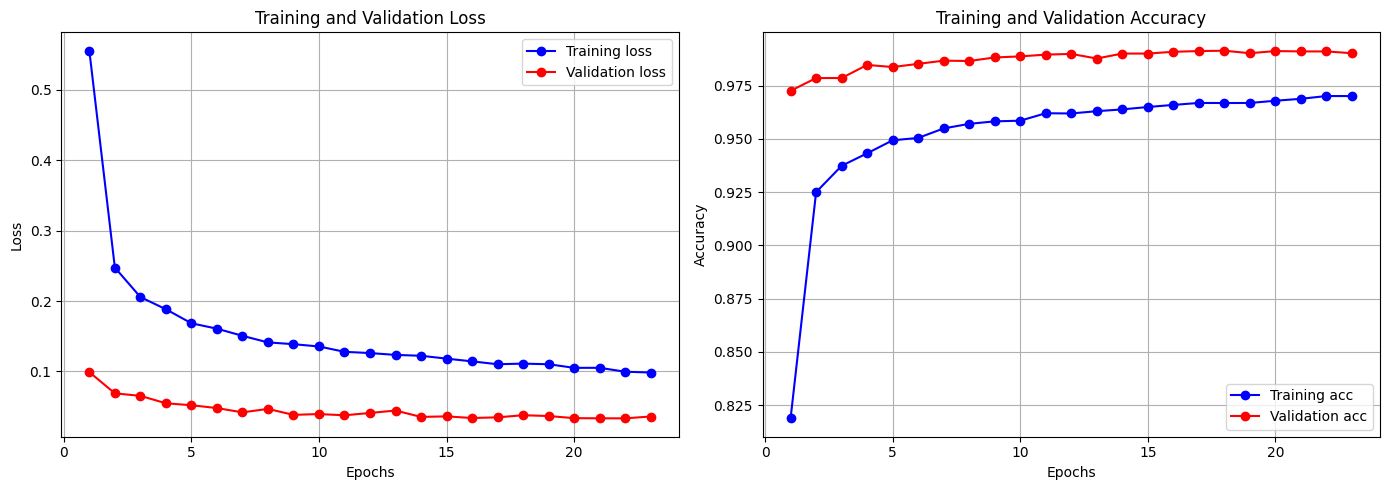

In [21]:
plot_train_history(history)

Las curvas de entrenamiento muestran que la pérdida disminuye mientras la exactitud aumenta tanto para la partición de entrenamiento como para la de validación. El punto importante es la relación entre las dos curvas: el desempeño de validación sigue la tendencia de entrenamiento en lugar de divergir bruscamente.

Ese patrón sugiere que el modelo está aprendiendo características que generalizan más allá de los batches aumentados de entrenamiento. No hay una señal visual fuerte de sobreajuste en estas curvas, porque la pérdida de validación permanece controlada y la exactitud de validación se mantiene cerca de la exactitud de entrenamiento.


## Prueba

La partición de prueba se usa solo después del entrenamiento y la selección del modelo. Esto la mantiene como una estimación no sesgada del desempeño final del benchmark sobre ejemplos de MNIST no vistos.


In [22]:
labels, predictions, images, probabilities = test_model(
    model=model, test_dataloader=test_loader, device=device
)

Las siguientes celdas evalúan el modelo sobre el dataloader de prueba reservado. En este punto, el modelo ya no aprende; solo produce predicciones usadas para el reporte.


## Matriz de Confusión

La matriz de confusión compara las etiquetas verdaderas contra las etiquetas predichas. Es especialmente útil para encontrar errores sistemáticos entre dígitos visualmente similares.


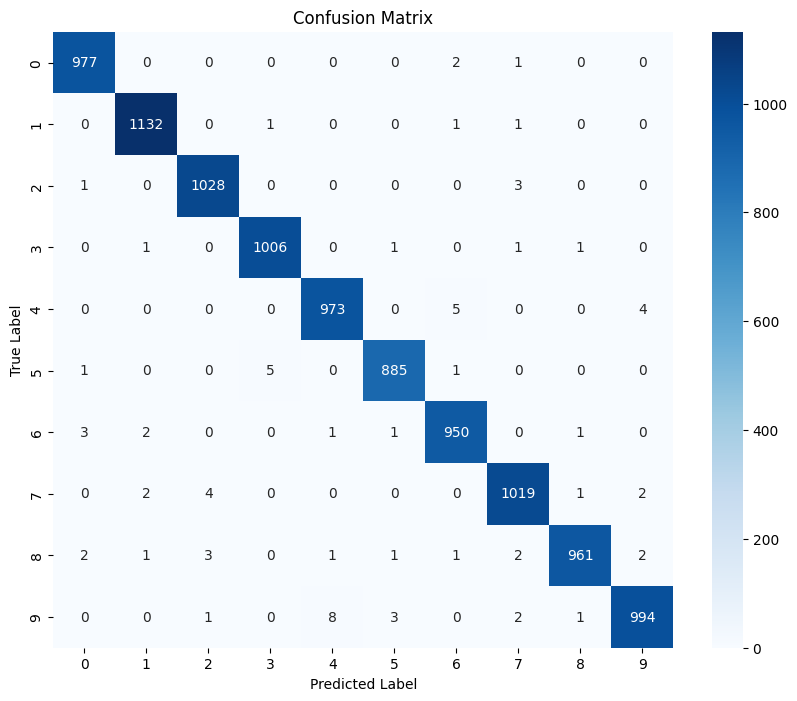

In [23]:
plot_confusion_matrix(labels, predictions, list(sorted(set(labels))))

La matriz de confusión muestra una fuerte generalización en las diez clases de dígitos, con la mayoría de las muestras concentradas en la diagonal. Los errores restantes se concentran en pares plausibles, como casos donde un `4` verdadero se predice como `9`.

Este tipo de error es comprensible porque algunas muestras manuscritas de `4` y `9` comparten bucles y trazos verticales similares. Una mejora dirigida sería recolectar o aumentar más ejemplos frontera para esos pares confusos, de modo que el modelo aprenda las diferencias sutiles de forma más explícita.


## Reporte de Clasificación

El reporte de clasificación complementa la exactitud al reportar precisión, recall y F1-score por clase. Esto ayuda a confirmar si el desempeño está balanceado entre todos los dígitos.


In [24]:
print_classification_report(labels, predictions, list(sorted(set(labels))))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       0.99      1.00      1.00      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



El reporte muestra precisión, recall y F1-score muy altos en todas las clases de dígitos.

La precisión responde: cuando el modelo predice una clase, ¿con qué frecuencia es correcto? El recall responde: entre todos los ejemplos verdaderos de una clase, ¿cuántos recuperó el modelo? El F1-score combina ambos en una única media armónica.

Como el dataset está balanceado, estos valores altos por clase son consistentes con la exactitud global e indican que el desempeño no está siendo impulsado solo por unas pocas clases fáciles.


## Log Loss

El reporte de clasificación evalúa decisiones de clase duras. Log loss evalúa la distribución de probabilidad detrás de esas decisiones, por lo que penaliza las predicciones incorrectas con alta confianza más fuertemente que los errores inciertos.

$$
        \mathcal{L} = -\log(\hat{p}_7)
$$


In [25]:
test_log_loss = log_loss(labels, probabilities, labels=list(sorted(set(labels))))
print(f"Log loss de prueba: {test_log_loss:.4f}")

Log loss de prueba: 0.0210


Un valor bajo de log loss significa que el modelo no solo elige la clase correcta la mayor parte del tiempo, sino que también asigna una masa de probabilidad fuerte al dígito correcto. Esto es importante para despliegue porque la calidad de la probabilidad importa cuando las predicciones se filtran por umbral, se ordenan o se revisan por confianza.

Si la exactitud se mantuviera alta pero el log loss aumentara, eso indicaría errores sobreconfiados. En esta evaluación, log loss debe leerse junto con la matriz de confusión y los F1-scores: el modelo comete pocos errores, y la métrica basada en probabilidad revisa si esos pocos errores también están bien calibrados.


## Visualización de Predicciones

Una grilla de predicciones proporciona una revisión cualitativa. Permite inspeccionar si las predicciones correctas corresponden solo a casos obvios, o si el modelo también maneja escritura ambigua.


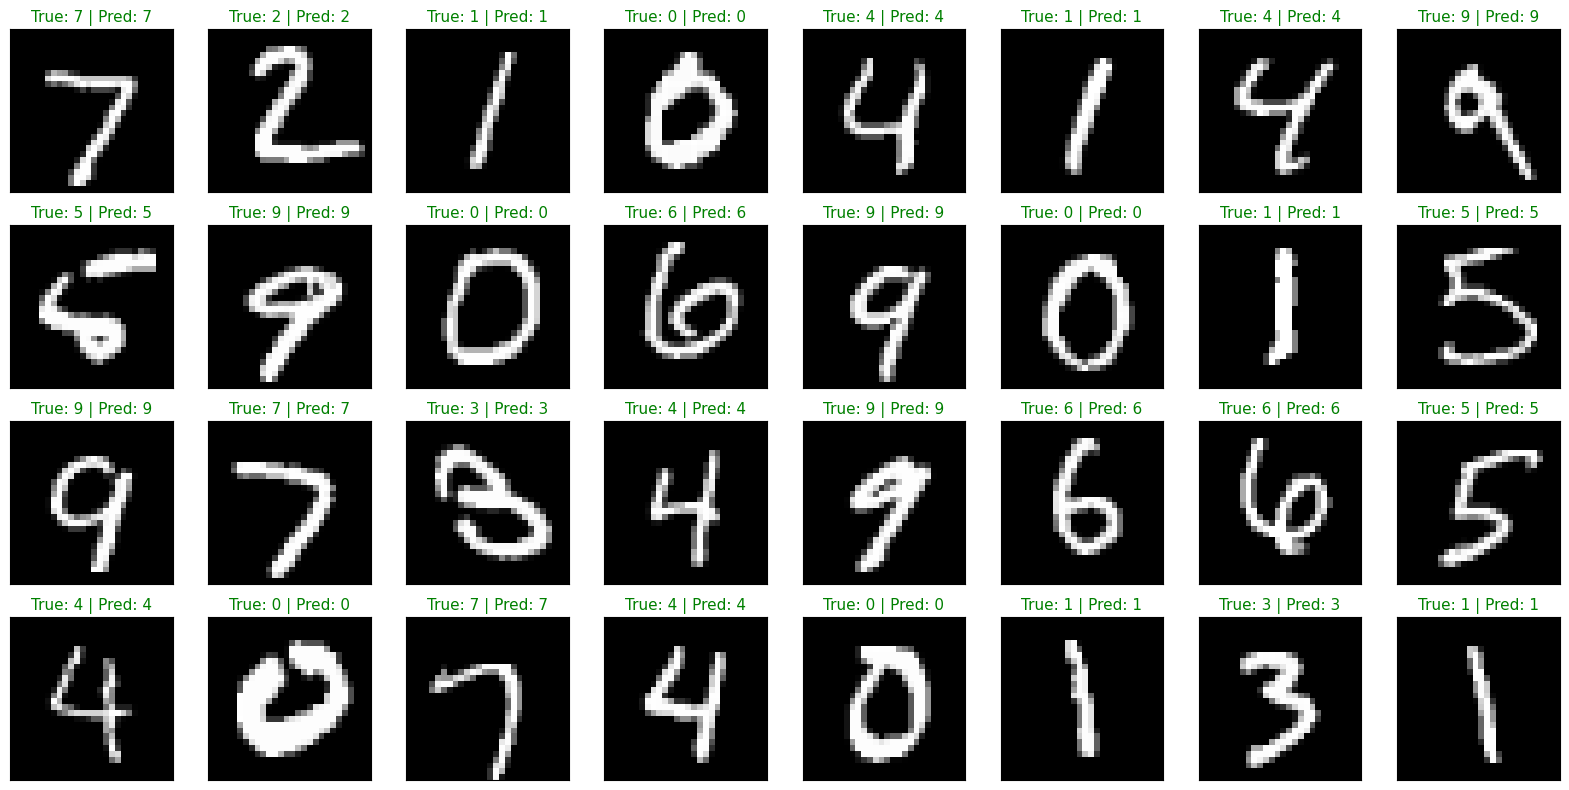

In [26]:
plot_predictions(images, labels, predictions, 32)

En este batch muestreado, el modelo predice correctamente los dígitos mostrados, incluyendo ejemplos que son visualmente menos limpios. Esto respalda las métricas cuantitativas: el clasificador no solo tiene buen desempeño en promedio, sino que también maneja varios trazos imperfectos y formas ambiguas.


## Predicciones con Dígitos Manuscritos Personalizados

Para ir más allá de la partición de prueba del benchmark, esta sección evalúa imágenes personalizadas de dígitos escritos a mano almacenadas en la carpeta `images/` del proyecto. Estas muestras son útiles porque son menos controladas que MNIST y, por lo tanto, proporcionan una prueba de robustez más realista.


In [27]:
folder_path = Path("../images")

image_paths = sorted(
    list(folder_path.glob("*.png"))
    + list(folder_path.glob("*.jpg"))
    + list(folder_path.glob("*.JPG"))
    + list(folder_path.glob("*.jpeg"))
)

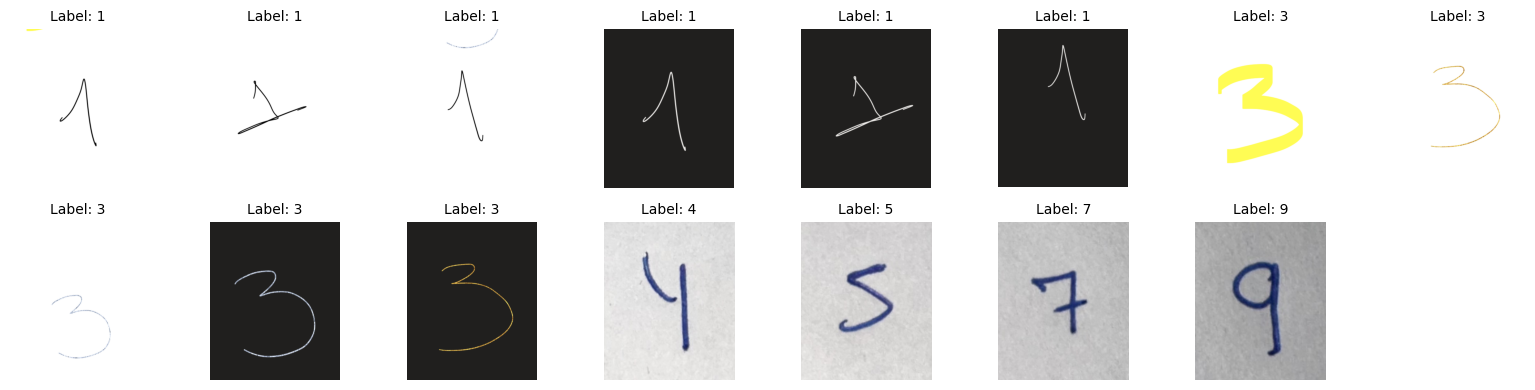

In [28]:
plot_hw_samples(image_paths)

In [29]:
images = []
filenames = []

for image_path in image_paths:
    tensor = preprocess_handwritten_image_with_transformation(image_path, unsqueeze=False)
    images.append(tensor)
    filenames.append(image_path.name)

images_tensor = torch.stack(images)
labels = [int(s[0]) for s in filenames]
print(labels)

[1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 4, 5, 7, 9]


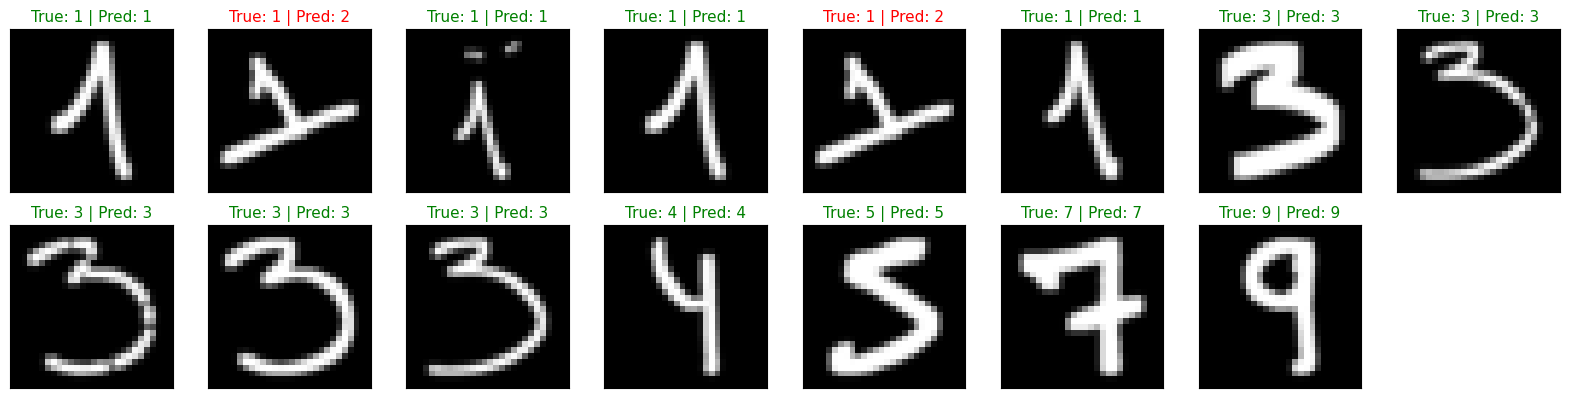

In [30]:
model.to(device)
model.eval()

with torch.inference_mode():
    images_device = images_tensor.to(device)
    output = model(images_device)
    predictions = output.argmax(dim=1)

plot_predictions(images_tensor, labels, predictions.cpu().numpy(), 15)

Las predicciones sobre imágenes personalizadas dependen fuertemente del pipeline de preprocesamiento en `preprocess_handwritten_image_with_transformation`. Este es el mismo tipo de preprocesamiento requerido por la ruta de la API, donde las imágenes entrantes pueden variar en color de fondo, contraste, saturación, encuadre y grosor del trazo.

El flujo de preprocesamiento adapta esas imágenes de vuelta hacia el formato de MNIST:
1. Convertir la imagen a escala de grises y aumentar el contraste para que el dígito sea más fácil de separar del fondo.
2. Inspeccionar el brillo de los bordes para inferir si el fondo es claro u oscuro, y luego invertir cuando sea necesario.
3. Aplicar umbralización a la imagen para que los píxeles grises se conviertan en valores limpios de primer plano o fondo.
4. Aplicar un filtro máximo para engrosar trazos delgados antes del redimensionamiento, reduciendo el riesgo de que el dígito desaparezca a resolución 28 x 28.
5. Recortar alrededor del dígito detectado con una caja delimitadora, y luego agregar padding para que la imagen final permanezca centrada y cuadrada.

Este paso es esencial porque el desempeño de benchmark en MNIST no garantiza automáticamente un buen comportamiento sobre imágenes manuscritas arbitrarias. Por lo tanto, los errores restantes en muestras personalizadas son útiles: señalan estilos de dígitos subrepresentados en los datos de entrenamiento y que podrían mejorarse con ejemplos adicionales dirigidos o aumento de datos.


# Conclusión

El modelo alcanza un desempeño fuerte en el conjunto de prueba de MNIST y se mantiene convincente bajo inspección cualitativa. Las curvas de entrenamiento sugieren aprendizaje estable, la matriz de confusión muestra pocos errores sistemáticos, y el reporte de clasificación confirma alta precisión, recall y F1-score en las clases de dígitos.

La métrica adicional de log loss fortalece la evaluación porque revisa la calidad de la probabilidad detrás de las etiquetas predichas. En conjunto, estas métricas indican que el modelo es preciso y, en general, confiado en los lugares correctos.

Los ejemplos personalizados de dígitos manuscritos son la prueba más exigente. Muestran que el preprocesamiento es una parte clave de la solución completa: sin adaptar imágenes reales al formato similar a MNIST, incluso un clasificador fuerte puede recibir entradas que difieren demasiado de lo que aprendió durante el entrenamiento.


# Mejoras Futuras

Varias mejoras podrían hacer que la solución sea más robusta y eficiente:
1. Reducir el tamaño del modelo. La red actual generaliza bien incluso con dropouts altos, lo que sugiere que una arquitectura más pequeña podría alcanzar un desempeño similar con menos parámetros y menor costo de inferencia.
2. Agregar early stopping. El proceso de entrenamiento actual es simple y efectivo, pero early stopping evitaría épocas innecesarias cuando el desempeño de validación ya se ha estabilizado.
3. Extender la evaluación basada en probabilidades. Log loss ya está incluido; análisis futuros podrían agregar curvas de calibración o error esperado de calibración para medir la calidad de la confianza de forma más directa.
4. Agregar datos dirigidos para clases confusas. Pares como `4` y `9`, o estilos manuscritos personalizados que fallan en la práctica, podrían mejorarse con ejemplos y aumentos enfocados.
5. Ampliar las pruebas del mundo real. Más muestras personalizadas con diferentes fondos, bolígrafos, condiciones de iluminación y estilos de escritura proporcionarían una mejor estimación del comportamiento en despliegue.
